# Predictive Maintenance Failure Prediction using Machine Learning

This project focuses on predicting machine failure using machine learning techniques based on operational and sensor data from industrial equipment.

The objective is to develop a predictive maintenance model that can identify potential failures before they occur, helping reduce downtime, maintenance costs, and operational risks.

The workflow includes:
- Data exploration and preprocessing
- Handling categorical and numerical features using a preprocessing pipeline
- Training and evaluating multiple machine learning models
- Selecting the best-performing model


In [27]:
import pandas as pd
df = pd.read_csv('ai4i2020.csv')
print(df.shape)
df.head()

df.describe()


(10000, 14)


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


 Machine failure vs other failure factors
 - TWF — Tool Wear Failure
 - HDF — Heat Dissipation Failure
 - PWF — Power Failure
 - OSF — Overstrain Failure
 - RNF — Random Failure

- Checking if product ids and UDIs are unique, if yes we need to drop them because the machine will memorize the IDs and this leads to bad generalization.

- Product ID being unique does not always automatically mean useless in real projects (sometimes IDs encode product family info), but here we already have Type, so keeping Product ID would mostly create noise/memorization.

In [28]:
print(f'Number of product ids: {df['Product ID'].nunique()}')
print(f'Number of UDIs: {df['UDI'].nunique()}')

# drop the columns
df = df.drop(['Product ID', 'UDI'], axis=1)


Number of product ids: 10000
Number of UDIs: 10000


In [7]:
print(df['Type'].unique())

['M' 'L' 'H']


In [8]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in failure_cols:
    print(f"\n-------------{col}-------------")

    table = pd.crosstab(
        df['Machine failure'],
        df[col]
    )

    table.columns.name = None
    table.index.name = 'Machine Failure'

    display(table)



-------------TWF-------------


,0,1
Machine Failure,,
0,9661,0
1,293,46



-------------HDF-------------


,0,1
Machine Failure,,
0,9661,0
1,224,115



-------------PWF-------------


,0,1
Machine Failure,,
0,9661,0
1,244,95



-------------OSF-------------


,0,1
Machine Failure,,
0,9661,0
1,241,98



-------------RNF-------------


,0,1
Machine Failure,,
0,9643,18
1,338,1


We dropped all failure subtype columns (TWF, HDF, PWF, OSF, RNF) because they represent failure diagnoses rather than predictive sensor inputs. Including them would cause data leakage, allowing the model to memorize failure outcomes instead of learning to predict failures from operational conditions.

In [29]:
df = df.drop(failure_cols, axis=1)


### Target imbalance visualization

Target variable is heavily imbalanced, with machine failures being much fewer than non-failures. Therefore, accuracy alone will not be a reliable evaluation metric.

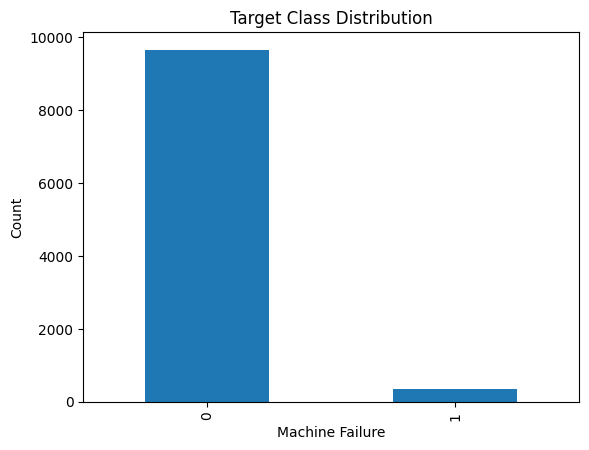

In [10]:
import matplotlib.pyplot as plt

df['Machine failure'].value_counts().plot(kind='bar')
plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.show()

 - Failed machines generally operate at higher torque levels, suggesting torque may be an important predictor of machine failure.

 - Although outliers are present, they may represent genuine abnormal machine operating conditions rather than erroneous data, so they should not be removed without domain justification.

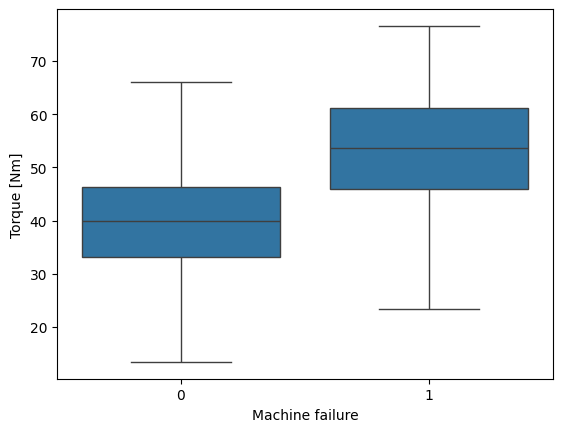

In [11]:
import seaborn as sns

sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df, showfliers = False)
plt.show()


 - Failed machines generally operate at lower rotational speeds compared to non-failed machines.
 - The distribution is narrower for failed machines, suggesting rotational speed may be an informative predictor.

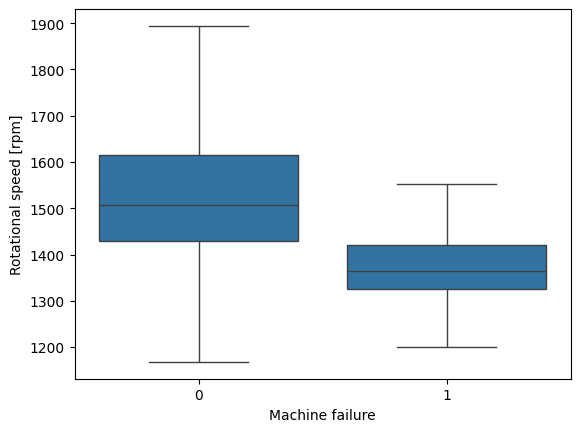

In [12]:
sns.boxplot(x='Machine failure', y='Rotational speed [rpm]', data=df, showfliers=False)
plt.show()

- Failed machines show a slightly higher process temperature than non-failed machines.
 - The separation is present but not very strong, so this may be a weaker predictor on its own.

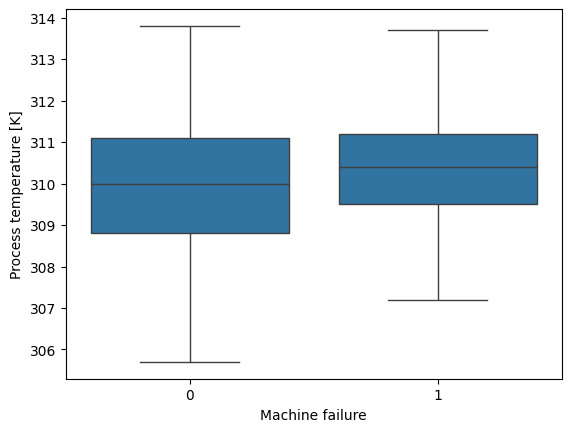

In [13]:
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df, showfliers=False)
plt.show()

 - Failed machines tend to operate at slightly higher air temperatures.
 - Similar to process temperature, the overlap is substantial, suggesting limited standalone predictive power.

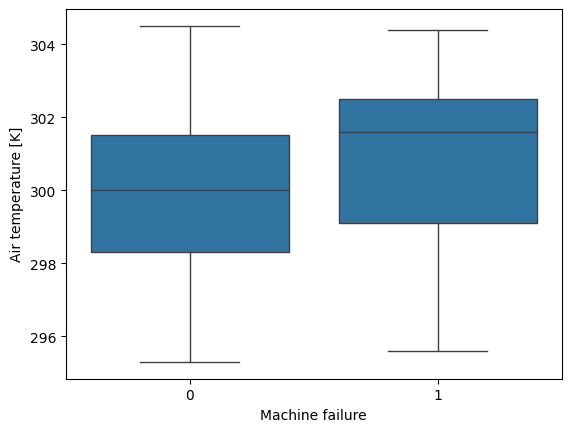

In [14]:
sns.boxplot(x='Machine failure', y='Air temperature [K]', data=df, showfliers=False)
plt.show()

 - Failed machines show significantly higher tool wear compared to non-failed machines.
 - This suggests tool wear is likely an important predictor of machine failure.

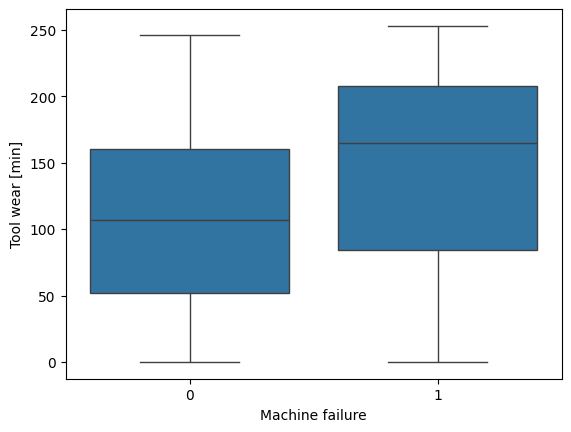

In [15]:
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df, showfliers=False)
plt.show()

Torque, tool wear, and rotational speed show clearer separation between failure and non-failure classes, while temperature features show weaker but potentially useful patterns.

# Heat map
Air temperature and process temperature show strong positive correlation, while rotational speed and torque show strong negative correlation. Torque and tool wear show the strongest direct association with machine failure, though overall linear correlations with the target are relatively weak, suggesting nonlinear models may capture more complex failure patterns.

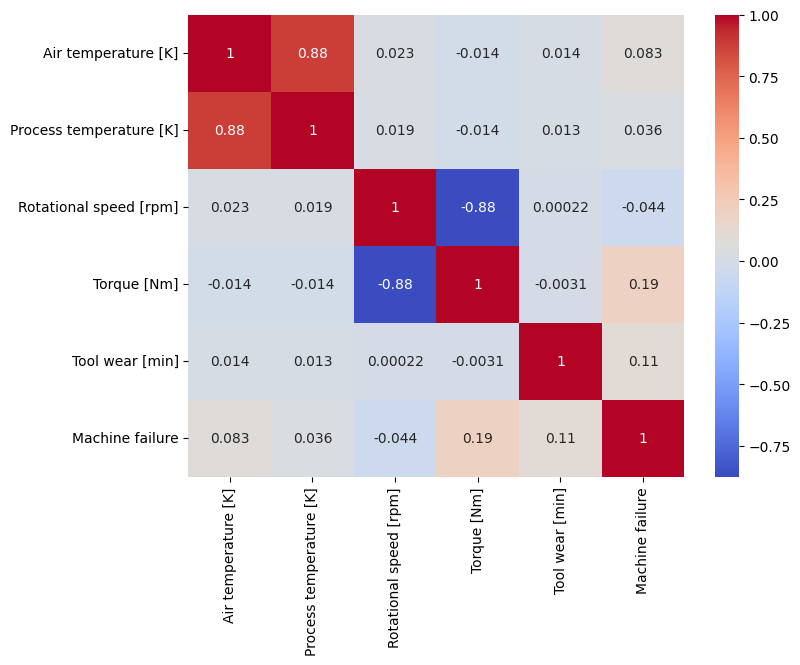

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

In [30]:
x = df.drop(['Machine failure'], axis=1)
y = df['Machine failure']
print("Feature Dataset (X):")
display(x.head())

print("\nTarget Variable (y):")
display(y.head())

Feature Dataset (X):


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9



Target Variable (y):


,Machine failure
0,0
1,0
2,0
3,0
4,0


## Data Preparation

The dataset was split into training and testing sets using an 80:20 ratio while preserving class distribution to ensure fair model evaluation.

A preprocessing pipeline was created using `ColumnTransformer` to handle different feature types:
- **Machine Type (`Type`)** was one-hot encoded since it is categorical.
- **Numerical features** were passed directly without modification.

This preprocessing was integrated into the model pipeline to ensure consistent transformations during both training and prediction.

In [18]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train,  X_test,y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


categorical_features = ['Type']
numeric_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

The baseline Logistic Regression achieved high overall accuracy due to class imbalance, but failure recall was very low (15%), indicating poor ability to detect actual machine failures. Since predictive maintenance prioritizes failure detection, accuracy is not an appropriate primary metric

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.67      0.15      0.24        68

    accuracy                           0.97      2000
   macro avg       0.82      0.57      0.61      2000
weighted avg       0.96      0.97      0.96      2000



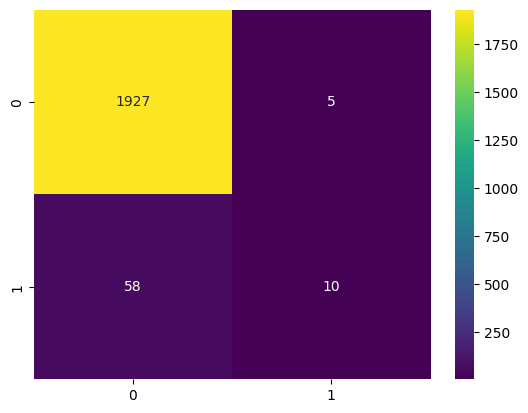

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


logreg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='viridis')
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



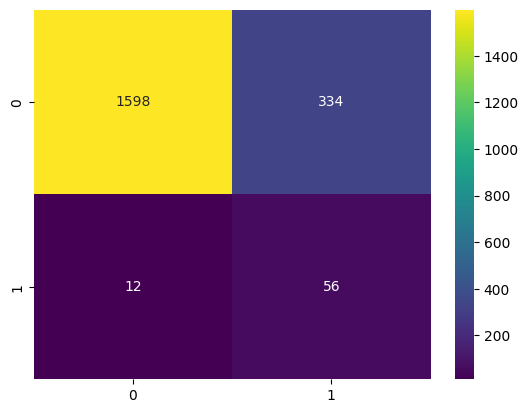

In [38]:
logreg_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ))
])

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='viridis')
print(classification_report(y_test, y_pred))

Random Forest significantly improved predictive performance over Logistic Regression, achieving high precision (90%) for failure prediction while maintaining moderate recall (51%). This indicates better balance between detecting failures and minimizing false alarms, making it a stronger baseline model for predictive maintenance.

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.89      0.50      0.64        68

    accuracy                           0.98      2000
   macro avg       0.94      0.75      0.82      2000
weighted avg       0.98      0.98      0.98      2000



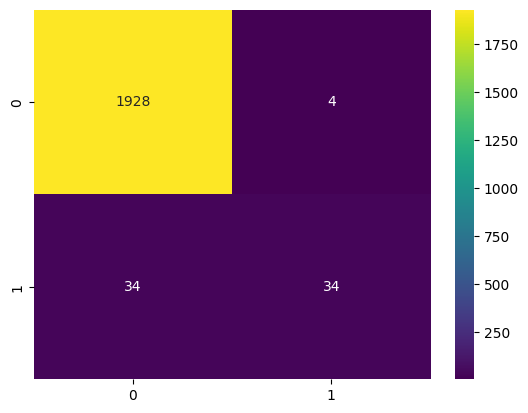

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessing',preprocessor),
    ('model', RandomForestClassifier())
])

rf_pipeline.fit(X_train,y_train)

y_pred = rf_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='viridis')
print(classification_report(y_test, y_pred))

XGBoost delivered the best performance, achieving strong failure detection recall (75%) while maintaining high precision (86%), making it the most balanced and practically useful model among the evaluated baselines.

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.75      0.80        68

    accuracy                           0.99      2000
   macro avg       0.93      0.87      0.90      2000
weighted avg       0.99      0.99      0.99      2000



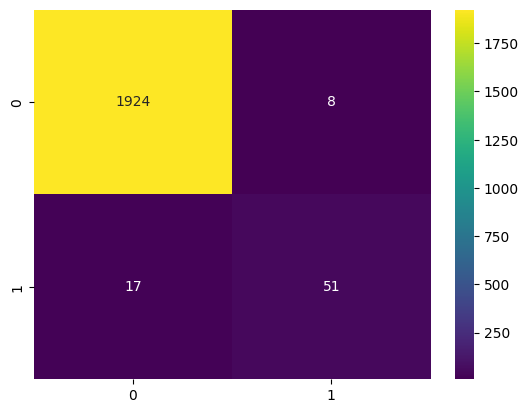

In [40]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier())
])

xgb_pipeline.fit(X_train, y_train)

y_pred = xgb_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='viridis')
print(classification_report(y_test, y_pred))

Tuning the XGboost

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)




Although the tuned XGBoost improved precision (fewer false alarms), it reduced recall compared to the original XGBoost model. Since the primary objective in predictive maintenance is to detect as many actual failures as possible and minimize missed failures, the original XGBoost model is preferred.

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



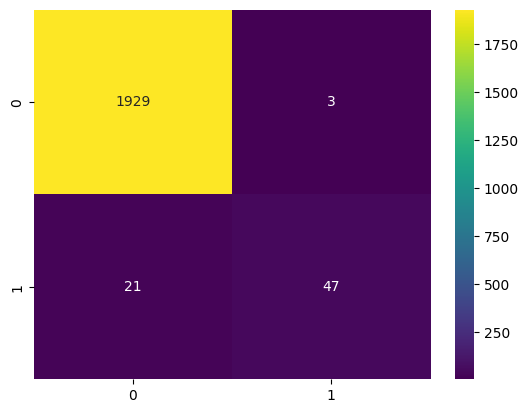

In [41]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='viridis')
print(classification_report(y_test, y_pred))

XGBoost feature importance analysis showed that torque was the most influential predictor of machine failure, followed by air temperature, tool wear, and rotational speed. This aligns with earlier exploratory analysis, where torque and tool wear showed clear separation between failure and non-failure cases.

In [25]:
xgb_model = xgb_pipeline.named_steps['model']
# xgb_model.feature_importances_
feature_names = xgb_pipeline.named_steps['preprocessing'].get_feature_names_out()
for name, importance in zip(feature_names, xgb_model.feature_importances_):
    print(name, importance)

cat__Type_H 0.053824954
cat__Type_L 0.067073815
cat__Type_M 0.11661463
num__Air temperature [K] 0.14805861
num__Process temperature [K] 0.10306456
num__Rotational speed [rpm] 0.12788214
num__Torque [Nm] 0.23701605
num__Tool wear [min] 0.14646527


SHAP analysis showed that high torque and increased tool wear strongly pushed predictions toward machine failure, while lower rotational speed also contributed to elevated failure risk. Product type had minimal influence, indicating that operational sensor measurements were the dominant predictors.

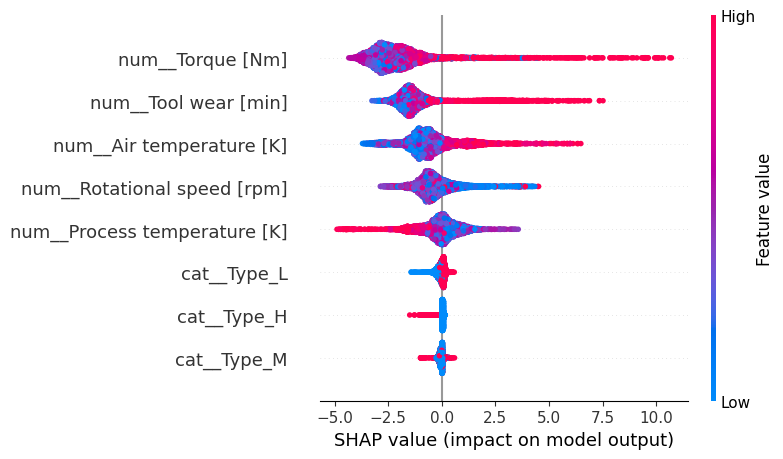

In [26]:
import shap
X_train_transformed = xgb_pipeline.named_steps['preprocessing'].transform(X_train)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)